In [1]:
#Fitting w0waCDM mock data

import numpy as np

import corner
from corner import quantile

from astropy.io import fits
from astropy.cosmology import w0waCDM
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import wCDM

import matplotlib.pyplot as plt

import statistics as stat

import matplotlib.image as mpimg
import matplotlib.lines as mlines

import pandas as pd

import scipy.stats as stats
from scipy import optimize
from scipy.stats import spearmanr
from scipy.stats import ks_2samp
from scipy.stats import chi2_contingency
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
from scipy.special import erfcinv
from scipy.special import erfinv

from anesthetic import Samples

import camb
from camb import model, initialpower
from camb.baseconfig import CAMBError

import nautilus.sampler as ns
from nautilus import Sampler
from nautilus import Prior

import h5py

from sklearn.metrics import r2_score

ns.h5py = h5py
print("Hello world")

Hello world


In [2]:
#Check all dependencies
import numpy, scipy, matplotlib, pandas, astropy, sklearn, h5py, camb, corner, anesthetic, nautilus

print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pandas.__version__)
print("astropy:", astropy.__version__)
print("sklearn:", sklearn.__version__)
print("h5py:", h5py.__version__)
print("camb:", camb.__version__)
print("corner:", corner.__version__)
print("anesthetic:", anesthetic.__version__)
print("nautilus:", nautilus.__version__)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
astropy: 7.2.0
sklearn: 1.7.2
h5py: 3.15.1
camb: 1.6.5
corner: 2.2.3
anesthetic: 2.11.0
nautilus: 1.0.5


In [3]:
#Reading the real data CSV file
df = pd.read_csv(
    'DES-Dovekie_HD.csv',
    comment='#',
    sep=r'\s+',
    engine='python'
)

In [4]:
#Selecting only the DES, CFA3, CFA4, CSP and Foundation Sne with zHD>=0.025 and a Probability of being SN1a above 0.9
allowed = [10, 63, 64, 65, 66, 150]

filtered = df[
    (df["IDSURVEY"].isin(allowed)) &
    (df["zHD"] >= 0.025) &
    (df["PROBIA_BEAMS"] > 0.9)
]

filtered.to_csv("filtered_supernova.csv", index=False)

In [5]:
#Reading the new resulting dataset
sn_real = pd.read_csv(
    'filtered_supernova.csv',
    engine='python'
)

print(len(sn_real))
print(len(sn_real[sn_real["IDSURVEY"] == 10]))
print(sn_real["zHD"].max(), sn_real["zHD"].min())

1687
1498
1.14418 0.02509


In [6]:
#Making an array with only the redshift and only the muerr
real_z = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_z[i] = sn_real.iloc[i, 3]

real_muerr = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_muerr[i] = sn_real.iloc[i, 6]

#Isolating the MU so we can compare later on with our synthetic data
real_mu = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_mu[i] = sn_real.iloc[i, 5]
    
real_zHEL = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_zHEL[i] = sn_real.iloc[i, 4]

In [7]:
#Functions to calculate likelihoods
def CMB_log_likelihood(CMB_model, CMB, inv_cov):
    delta = np.array([CMB_model - CMB])
    deltaT = np.transpose(delta)
    chi2 = np.sum(delta @ inv_cov @ deltaT)
    return -0.5*chi2

def BAO_log_likelihood(BAO_model, BAO, inv_cov):
    delta = np.array([BAO_model - BAO])
    deltaT = np.transpose(delta)
    chi2 = np.sum(delta @ inv_cov @ deltaT)
    return -0.5*chi2

def cov_log_likelihood(mu_model, mu, inv_cov):
    delta = np.array(mu_model) - np.array(mu)
    deltaT = np.transpose(delta)
    chit2 = np.sum(delta @ inv_cov @ deltaT)
    B = np.sum(delta @ inv_cov)
    C = np.sum(inv_cov)
    chi2 = chit2 - (B**2 / C) + np.log(C / (2 * np.pi))
    return -0.5*chi2

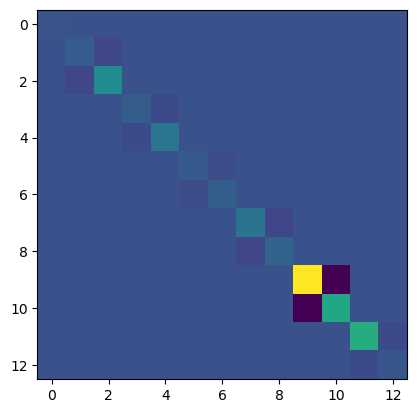

In [8]:
#Covarience matrix for BAO and CMB and SN only diag

corr_CMB1 = [[1, 0.46, -0.66],[0.46, 1, -0.33],[-0.66, -0.33, 1]]
corr_CMB = np.array(corr_CMB1)

sigmas = np.array([0.0046, 0.0895, 0.00015])

cov_CMB = np.diag(sigmas) @ corr_CMB @ np.diag(sigmas)

# Inverse covariance (precision matrix)
inv_CMB = np.linalg.inv(cov_CMB)

#BAO cov

zeff = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])
BAO_errors = [0.075, 0.167, 0.425, 0.177, 0.330, 0.152, 0.193, 0.318, 0.221, 0.760, 0.516, 0.531, 0.101]
BAO_sd = []

for i in range(len(BAO_errors)):
    BAO_sd.append(BAO_errors[i]**2)

BAO_cov = np.diag(BAO_sd)
BAO_corr = [-0.459, -0.404, -0.416, -0.434, -0.500, -0.431]

for i, rho in enumerate(BAO_corr):
    dm_idx = 2*i + 1   # Dm index
    dh_idx = 2*i + 2   # Dh index

    cov = rho * BAO_errors[dm_idx] * BAO_errors[dh_idx]
    BAO_cov[dm_idx, dh_idx] = cov
    BAO_cov[dh_idx, dm_idx] = cov
    
inv_BAO = np.linalg.inv(BAO_cov)

plt.imshow(BAO_cov)

cng = np.random.default_rng()
bng = np.random.default_rng()
rng = np.random.default_rng()

In [9]:
def MU(z, zHEL):
    result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
    return result

In [10]:
#All likelyhoods and priors

def likelyhoodSN_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    #Enforcing w0+wa<0, any time this combination occurs, likelyhood returned is -infinity

    if w0 + wa >= 0:
        return -np.inf
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        def MU(z, zHEL):
            result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
            return result

        test_mu = []
        for i in range(1500):
            test_mu.append(MU(synth_z[i],synth_zHEL[i]))

        return cov_log_likelihood(test_mu, synth_mu, inv_SN)

    except CAMBError:
        return -np.inf
    
#BAO likelyhood:
def likelyhoodBAO_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    if w0 + wa >= 0:
        return -np.inf
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_synth, inv_BAO)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodCMB_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    if w0 + wa >= 0:
        return -np.inf
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_synth, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#######################################
    
def likelyhoodSN_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        def MU(z, zHEL):
            result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
            return result

        test_mu = []
        for i in range(1500):
            test_mu.append(MU(synth_z[i],synth_zHEL[i]))

        return cov_log_likelihood(test_mu, synth_mu, inv_SN)
    
    except CAMBError:
        return -np.inf


def likelyhoodBAO_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_synth, inv_BAO)
    
    except CAMBError:
        return -np.inf

def likelyhoodCMB_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_synth, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#######################################
    
def likelyhoodSN_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        def MU(z, zHEL):
            result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
            return result

        test_mu = []
        for i in range(1500):
            test_mu.append(MU(synth_z[i],synth_zHEL[i]))

        return cov_log_likelihood(test_mu, synth_mu, inv_SN)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodBAO_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_synth, inv_BAO)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodCMB_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_synth, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#####################################################################################################################

#Priors for the evidence sampling
#w0waCDM
prior_w0waCDM_est = Prior()
prior_w0waCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_w0waCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_w0waCDM_est.add_parameter('wa', dist=(-3,+2))
prior_w0waCDM_est.add_parameter('w0', dist=(-3, -0.4))
prior_w0waCDM_est.add_parameter('H0', dist=(+55, +91))

#wCDM
prior_wCDM_est = Prior()
prior_wCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_wCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_wCDM_est.add_parameter('w0', dist=(-3,-0.4))
prior_wCDM_est.add_parameter('H0', dist=(+55, +91))

#LCDM
prior_LCDM_est = Prior()
prior_LCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_LCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_LCDM_est.add_parameter('H0', dist=(+55, +91))

#####################################################################################################################

#Likelihoods for probe combination

def likelyhoodSN_CMB_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodCMB_w0waCDM(theta)

def likelyhoodSN_CMB_BAO_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodCMB_w0waCDM(theta) + likelyhoodBAO_w0waCDM(theta)

def likelyhoodSN_BAO_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodBAO_w0waCDM(theta)

#######################################

def likelyhoodSN_CMB_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodCMB_wCDM(theta)

def likelyhoodSN_CMB_BAO_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodCMB_wCDM(theta) + likelyhoodBAO_wCDM(theta)

def likelyhoodSN_BAO_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodBAO_wCDM(theta)

#######################################

def likelyhoodSN_CMB_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodCMB_LCDM(theta)

def likelyhoodSN_CMB_BAO_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodCMB_LCDM(theta) + likelyhoodBAO_LCDM(theta)

def likelyhoodSN_BAO_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodBAO_LCDM(theta)

In [11]:
#Rerunning the sampler for the real data with no supernova covariances for comparison. Make sure you run
#these in the real no covmat notebook FIRST and set the path to the output files in the samplers below

#The samplers...

samplerSN_CMB_BAO_w0waCDM__est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = f"nocov_w0wa.h5")
samplerSN_CMB_BAO_w0waCDM__est.run(verbose=True)

#######################################

samplerSN_CMB_BAO_wCDM__est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, filepath = f"nocov_w.h5")
samplerSN_CMB_BAO_wCDM__est.run(verbose=True)

#######################################

samplerSN_CMB_BAO_LCDM__est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = f"nocov_L.h5")
samplerSN_CMB_BAO_LCDM__est.run(verbose=True)

####################################### extracting all the points, weights and likelihoods and posterior covariance matrix

#for w0waCDM
points_SN_CMB_BAO_w0waCDM_real, log_w_SN_CMB_BAO_w0waCDM_real, log_l_SN_CMB_BAO_w0waCDM_real = samplerSN_CMB_BAO_w0waCDM__est.posterior()
weights_SN_CMB_BAO_w0waCDM_real = np.exp(log_w_SN_CMB_BAO_w0waCDM_real)

labels_SN_CMB_BAO_w0waCDM_real = list(prior_w0waCDM_est.keys)

samples_SN_CMB_BAO_w0waCDM_real = Samples(points_SN_CMB_BAO_w0waCDM_real, 
                  weights=weights_SN_CMB_BAO_w0waCDM_real,
                  columns=labels_SN_CMB_BAO_w0waCDM_real)
cov_w0wa_real = samples_SN_CMB_BAO_w0waCDM_real.cov()

#######################################

#for wCDM
points_SN_CMB_BAO_wCDM_real, log_w_SN_CMB_BAO_wCDM_real, log_l_SN_CMB_BAO_wCDM_real = samplerSN_CMB_BAO_wCDM__est.posterior()
weights_SN_CMB_BAO_wCDM_real = np.exp(log_w_SN_CMB_BAO_wCDM_real)

labels_SN_CMB_BAO_wCDM_real = list(prior_wCDM_est.keys)

samples_SN_CMB_BAO_wCDM_real = Samples(points_SN_CMB_BAO_wCDM_real, 
                  weights=weights_SN_CMB_BAO_wCDM_real,
                  columns=labels_SN_CMB_BAO_wCDM_real)
cov_w_real = samples_SN_CMB_BAO_wCDM_real.cov()

#######################################

#for LCDM
points_SN_CMB_BAO_LCDM_real, log_w_SN_CMB_BAO_LCDM_real, log_l_SN_CMB_BAO_LCDM_real = samplerSN_CMB_BAO_LCDM__est.posterior()
weights_SN_CMB_BAO_LCDM_real = np.exp(log_w_SN_CMB_BAO_LCDM_real)

labels_SN_CMB_BAO_LCDM_real = list(prior_LCDM_est.keys)

samples_SN_CMB_BAO_LCDM_real = Samples(points_SN_CMB_BAO_LCDM_real, 
                  weights=weights_SN_CMB_BAO_LCDM_real,
                  columns=labels_SN_CMB_BAO_LCDM_real)
cov_L_real = samples_SN_CMB_BAO_LCDM_real.cov()

#Best-fit parameters with symmetrised errors to put in Table 4 in the paper

# w0waCDM with symmetrised errors
for i, p in enumerate(prior_w0waCDM_est.keys):
    q16, q50, q84 = corner.quantile(
        points_SN_CMB_BAO_w0waCDM_real[:, i],
        [0.1585, 0.5, 0.8415],
        weights=weights_SN_CMB_BAO_w0waCDM_real
    )
    
    err_minus = q50 - q16
    err_plus  = q84 - q50
    sd = 0.5 * (err_plus + err_minus)
    
    print(f"w0wa_{p} = {q50:.5g} | {sd:.5g}")


# wCDM 
for i, p in enumerate(prior_wCDM_est.keys):
    q16, q50, q84 = corner.quantile(
        points_SN_CMB_BAO_wCDM_real[:, i],
        [0.1585, 0.5, 0.8415],
        weights=weights_SN_CMB_BAO_wCDM_real
    )
    
    err_minus = q50 - q16
    err_plus  = q84 - q50
    sd = 0.5 * (err_plus + err_minus)
    
    print(f"w_{p} = {q50:.5g} | {sd:.5g}")


# LCDM 
for i, p in enumerate(prior_LCDM_est.keys):
    q16, q50, q84 = corner.quantile(
        points_SN_CMB_BAO_LCDM_real[:, i],
        [0.1585, 0.5, 0.8415],
        weights=weights_SN_CMB_BAO_LCDM_real
    )
    
    err_minus = q50 - q16
    err_plus  = q84 - q50
    sd = 0.5 * (err_plus + err_minus)
    
    print(f"L_{p} = {q50:.5g} | {sd:.5g}")
    
#For the best-fit parameter vectors for tension calculations later
    
data_w0wa_real = np.zeros(5)

for i, p in enumerate(prior_w0waCDM_est.keys):
    data_w0wa_real[i] = corner.quantile(points_SN_CMB_BAO_w0waCDM_real[:, i], [0.5], weights=weights_SN_CMB_BAO_w0waCDM_real)[0]
    
data_w_real = np.zeros(4)

for i, p in enumerate(prior_wCDM_est.keys):
    data_w_real[i] = corner.quantile(points_SN_CMB_BAO_wCDM_real[:, i], [0.5], weights=weights_SN_CMB_BAO_wCDM_real)[0]
    
data_L_real = np.zeros(3)

for i, p in enumerate(prior_LCDM_est.keys):
    data_L_real[i] = corner.quantile(points_SN_CMB_BAO_LCDM_real[:, i], [0.5], weights=weights_SN_CMB_BAO_LCDM_real)[0]

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39200    | N/A    | 10050 | -834.62  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 32     | 1        | 4        | 68400    | N/A    | 14709 | -842.48  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30400    | N/A    | 10007 | -843.09  
w0wa_omb = 0.049543 | 0.0006665
w0wa_Om0 = 0.31841 | 0.0045022
w0wa_wa = -0.91107 | 0.23086
w0wa_w0 = -0.75581 | 0.049116
w0wa_H0 = 67.269 | 0.43182
w_omb = 0.050122 | 0.00067416
w_Om0 = 0.31299 | 0.0041407
w_w0 = -0.94509 | 0.017951
w_H0 = 67.

In [12]:
#And also defining a function to calculate tension with mahalanobis distance
def tension(mu1, cov1, mu2, cov2):
    delta = np.array(mu1) - np.array(mu2)
    cov = np.array(cov1) + np.array(cov2)
    inv_cov = np.linalg.inv(cov)
    d2 = delta.T @ inv_cov @ delta
    dof = len(delta)
    PTE = chi2.sf(d2, dof)
    print("d2 =", d2)
    print("PTE =", PTE)
    return np.sqrt(2) * erfinv(1 - PTE)

In [13]:
#50 Realisations of w0waCDM mock data with w0waCDM, wCDM and LCDM models fit.

ombh2 = 0.02236
omch2 = 0.1202
H0 = 67.47
rstar = 144.39
zdrag = 1059.93
rdrag = 147.05
w = -0.803
wa = -0.72
c = 299792.458

#counters for incidences of spurious mimicky set to 0
w0wa_tension_count = 0
w_tension_count = 0
L_tension_count = 0
full_tension_count = 0

#Arrays to store best fit parameters in each realisation
#w0waCDM
W0 = np.zeros(50)
W0err = np.zeros((50,2))
WA = np.zeros(50)
WAerr = np.zeros((50,2))
HUBwaw0 = np.zeros(50)
HUBwaw0err = np.zeros((50,2))
Om0waw0 = np.zeros(50)
Om0waw0err = np.zeros((50,2))
ombwaw0 = np.zeros(50)

#wCDM
W = np.zeros(50)
Werr = np.zeros((50,2))
HUBw = np.zeros(50)
HUBwerr = np.zeros((50,2))
Om0w = np.zeros(50)
Om0werr = np.zeros((50,2))
ombw = np.zeros(50)

#LCDM
HUBL = np.zeros(50)
HUBLerr = np.zeros((50,2))
Om0L = np.zeros(50)
Om0Lerr = np.zeros((50,2))
ombL = np.zeros(50)

#Storing evidences for each model each realisation
ev_w0wa = np.zeros(50)
ev_w = np.zeros(50)
ev_L = np.zeros(50)

#Coverage for 0, 20, 40, 60, 80, 100 regions for each parameter
pipeline_checkw0 = np.zeros(6)
pipeline_checkwa = np.zeros(6)
pipeline_checkOm0 = np.zeros(6)
pipeline_checkH = np.zeros(6)


for u in range(50):
    
    # Randomly sample 1500 unique entries
    idx = np.random.choice(sn_real.shape[0], size=1500, replace=True)
    random_sn = sn_real.iloc[idx]

    synth_z = np.zeros(len(random_sn))
    synth_zHEL = np.zeros(len(random_sn))
    
    #Randomly select 1500 redshifts
    for i in range(len(random_sn)):
        synth_z[i] = random_sn.iloc[i, 3]
        synth_zHEL[i] = random_sn.iloc[i, 4]

    #Corresponding distance modulus and error
    real_mu_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_mu_corresponding_to_z[i] = random_sn.iloc[i, 5]

    real_muerr_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_muerr_corresponding_to_z[i] = random_sn.iloc[i, 6]
       
    #Make diagonal SN covmat with random errors
    SN_sd = []

    for z in range(len(real_muerr_corresponding_to_z)):
        SN_sd.append(real_muerr_corresponding_to_z[z]**2)

    SN_cov = np.diag(SN_sd)

    inv_SN = np.linalg.inv(SN_cov)
        
    #Producing synthetic CMB data

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0,
        ombh2=ombh2,
        omch2=omch2,
        omk=0)

    pars.set_dark_energy(
    w=w,
    wa=wa,
    dark_energy_model='ppf'
    )

    h = H0 / 100.0
    Om0 = (ombh2 + omch2) / h**2
    ommh2 = ombh2 + omch2

    results = camb.get_background(pars)
    CMB_theory = np.zeros(3)

    g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
    g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
    zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

    #Calculate R
    CMB_theory[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
    #Calculate la
    CMB_theory[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
    #Input ombh2
    CMB_theory[2] = ombh2

    noise_CMB = cng.multivariate_normal(mean=np.zeros(3), cov=cov_CMB)

    #Add noise to each point
    CMB_synth = CMB_theory + noise_CMB

    #Now BAO

    r_d = results.get_derived_params()['rdrag']
    H = results.hubble_parameter(zeff)
    Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
    Dm_rd = Dm /r_d
    Dh = c/H
    Dh_rd = Dh/r_d

    BAO_theory = np.zeros(13)

    BAO_theory[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
    BAO_theory[1] = Dm_rd[1]
    BAO_theory[2] = Dh_rd[1]
    BAO_theory[3] = Dm_rd[2]
    BAO_theory[4] = Dh_rd[2]
    BAO_theory[5] = Dm_rd[3]
    BAO_theory[6] = Dh_rd[3]
    BAO_theory[7] = Dm_rd[4]
    BAO_theory[8] = Dh_rd[4]
    BAO_theory[9] = Dm_rd[5]
    BAO_theory[10] = Dh_rd[5]
    BAO_theory[11] = Dm_rd[6]
    BAO_theory[12] = Dh_rd[6]

    noise_BAO = bng.multivariate_normal(mean=np.zeros(13), cov=BAO_cov)

    #Add noise to each point
    BAO_synth = BAO_theory + noise_BAO

    #Now SN with noise added to each point

    synth_mu = []
    for i in range(1500):
        synth_mu.append(MU(synth_z[i],synth_zHEL[i]) + rng.normal(loc=0.0, scale=real_muerr_corresponding_to_z[i], size=None))
        
    #run samplers to fit w0waCDM, wCDM and LCDM
    
    samplerSN_CMB_BAO_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = f"__Nooisyw0wa_w0wa/{u}.h5")
    samplerSN_CMB_BAO_w0waCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, n_live=1000, filepath = f"__Nooisyw0wa_w/{u}.h5")
    samplerSN_CMB_BAO_wCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = f"__Nooisyw0wa_L/{u}.h5")
    samplerSN_CMB_BAO_LCDM_est.run(verbose=True)
    
    #Extract points, log weights, and log likelihoods
    points_SN_CMB_BAO_w0waCDM_est, log_w_SN_CMB_BAO_w0waCDM_est, log_l_SN_CMB_BAO_w0waCDM_est = samplerSN_CMB_BAO_w0waCDM_est.posterior()
    points_SN_CMB_BAO_wCDM_est, log_w_SN_CMB_BAO_wCDM_est, log_l_SN_CMB_BAO_wCDM_est = samplerSN_CMB_BAO_wCDM_est.posterior()
    points_SN_CMB_BAO_LCDM_est, log_w_SN_CMB_BAO_LCDM_est, log_l_SN_CMB_BAO_LCDM_est = samplerSN_CMB_BAO_LCDM_est.posterior()
    
    #Exponentiate the weights, and isolate the points for each parameter
    #for w0waCDM
    weights_SN_CMB_BAO_w0waCDM_est = np.exp(log_w_SN_CMB_BAO_w0waCDM_est)
    labels_SN_CMB_BAO_w0waCDM_est = list(prior_w0waCDM_est.keys)
    w0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 3]  
    wa_samples = points_SN_CMB_BAO_w0waCDM_est[:, 2] 
    Om0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 1]
    H_samples = points_SN_CMB_BAO_w0waCDM_est[:, 4]
    omb_samples = points_SN_CMB_BAO_w0waCDM_est[:, 0]
    
    #Extract the posterior covariance
    samples_SN_CMB_BAO_w0waCDM_est = Samples(points_SN_CMB_BAO_w0waCDM_est, 
                  weights=weights_SN_CMB_BAO_w0waCDM_est,
                  columns=labels_SN_CMB_BAO_w0waCDM_est)
    cov_SN_CMB_BAO_w0waCDM_est = samples_SN_CMB_BAO_w0waCDM_est.cov()
    
    #for wCDM
    weights_SN_CMB_BAO_wCDM_est = np.exp(log_w_SN_CMB_BAO_wCDM_est)
    labels_SN_CMB_BAO_wCDM_est = list(prior_wCDM_est.keys)
    w02_samples = points_SN_CMB_BAO_wCDM_est[:, 2]  # index of w0
    Om02_samples = points_SN_CMB_BAO_wCDM_est[:, 1]
    H2_samples = points_SN_CMB_BAO_wCDM_est[:, 3]
    omb2_samples = points_SN_CMB_BAO_wCDM_est[:, 0]
    
    #Extract the posterior covariance
    samples_SN_CMB_BAO_wCDM_est = Samples(points_SN_CMB_BAO_wCDM_est, 
                  weights=weights_SN_CMB_BAO_wCDM_est,
                  columns=labels_SN_CMB_BAO_wCDM_est)
    cov_SN_CMB_BAO_wCDM_est = samples_SN_CMB_BAO_wCDM_est.cov()
    
    #for LCDM
    weights_SN_CMB_BAO_LCDM_est = np.exp(log_w_SN_CMB_BAO_LCDM_est)
    labels_SN_CMB_BAO_LCDM_est = list(prior_LCDM_est.keys)
    Om03_samples = points_SN_CMB_BAO_LCDM_est[:, 1]
    H3_samples = points_SN_CMB_BAO_LCDM_est[:, 2]
    omb3_samples = points_SN_CMB_BAO_LCDM_est[:, 0]
    
    #Extract the posterior covariance
    samples_SN_CMB_BAO_LCDM_est = Samples(points_SN_CMB_BAO_LCDM_est, 
                  weights=weights_SN_CMB_BAO_LCDM_est,
                  columns=labels_SN_CMB_BAO_LCDM_est)
    cov_SN_CMB_BAO_LCDM_est = samples_SN_CMB_BAO_LCDM_est.cov()

    #Extract the quantiles for each parameter
    #for w0waCDM with extra quantiles for the coverage check
    w0wa_q10w0, w0wa_q16w0, w0wa_q20w0, w0wa_q30w0, w0wa_q40w0, w0wa_q50w0, w0wa_q60w0, w0wa_q70w0, w0wa_q80w0, w0wa_q8w0, w0wa_q90w0 = quantile(w0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10wa, w0wa_q16wa, w0wa_q20wa, w0wa_q30wa, w0wa_q40wa, w0wa_q50wa, w0wa_q60wa, w0wa_q70wa, w0wa_q80wa, w0wa_q8wa, w0wa_q90wa = quantile(wa_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10Om0, w0wa_q16Om0, w0wa_q20Om0, w0wa_q30Om0, w0wa_q40Om0, w0wa_q50Om0, w0wa_q60Om0, w0wa_q70Om0, w0wa_q80Om0, w0wa_q8Om0, w0wa_q90Om0 = quantile(Om0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10H, w0wa_q16H, w0wa_q20H, w0wa_q30H, w0wa_q40H, w0wa_q50H, w0wa_q60H, w0wa_q70H, w0wa_q80H, w0wa_q8H, w0wa_q90H = quantile(H_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10omb, w0wa_q16omb, w0wa_q20omb, w0wa_q30omb, w0wa_q40omb, w0wa_q50omb, w0wa_q60omb, w0wa_q70omb, w0wa_q80omb, w0wa_q8omb, w0wa_q90omb = quantile(omb_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    
    #for wCDM
    w_q16w02, w_q50w02, w_q8w02 = quantile(w02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16Om02, w_q50Om02, w_q8Om02 = quantile(Om02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16H2, w_q50H2, w_q8H2 = quantile(H2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16omb2, w_q50omb2, w_q8omb2 = quantile(omb2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    
    #for LCDM
    L_q16Om03, L_q50Om03, L_q8Om03 = quantile(Om03_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16H3, L_q50H3, L_q8H3 = quantile(H3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16omb3, L_q50omb3, L_q8omb3 = quantile(omb3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    
    #Extract evidence for each model
    log_z_w0wa = samplerSN_CMB_BAO_w0waCDM_est.log_z
    log_z_w = samplerSN_CMB_BAO_wCDM_est.log_z
    log_z_L = samplerSN_CMB_BAO_LCDM_est.log_z
    
    #Input medians and errors into the arrays defined above for each parameter
    #for w0waCDM
    W0[u] = w0wa_q50w0
    W0err[u,0] = w0wa_q50w0 - w0wa_q16w0
    W0err[u,1] = w0wa_q8w0 - w0wa_q50w0
    WA[u] = w0wa_q50wa
    WAerr[u,0] = w0wa_q50wa - w0wa_q16wa
    WAerr[u,1] = w0wa_q8wa - w0wa_q50wa
    HUBwaw0[u] = w0wa_q50H
    HUBwaw0err[u,0] = w0wa_q50H - w0wa_q16H
    HUBwaw0err[u,1] = w0wa_q8H - w0wa_q50H
    Om0waw0[u] = w0wa_q50Om0
    Om0waw0err[u,0] = w0wa_q50Om0 - w0wa_q16Om0
    Om0waw0err[u,1] = w0wa_q8Om0 - w0wa_q50Om0
    ombwaw0[u] = w0wa_q50omb
    
    #Toggle number at the end of if statements to change significance level we want to count indidences at.
    #Counting number of times w0waCDM data can reproduce w0waCDM best fit parameters from the real no covmat data
    dataw0wa = np.array((ombwaw0[u], Om0waw0[u], WA[u], W0[u], HUBwaw0[u]))
    if tension(dataw0wa, cov_SN_CMB_BAO_w0waCDM_est, data_w0wa_real, cov_w0wa_real) < 1:
        w0wa_tension_count += 1

    #for wCDM
    W[u] = w_q50w02
    Werr[u,0] = w_q50w02 - w_q16w02
    Werr[u,1] = w_q8w02 - w_q50w02
    HUBw[u] = w_q50H2
    HUBwerr[u,0] = w_q50H2 - w_q16H2
    HUBwerr[u,1] = w_q8H2 - w_q50H2
    Om0w[u] = w_q50Om02
    Om0werr[u,0] = w_q50Om02 - w_q16Om02
    Om0werr[u,1] = w_q8Om02 - w_q50Om02
    ombw[u] = w_q50omb2
    
    #Counting number of times w0waCDM data can reproduce wCDM best fit parameters from the real no covmat data
    dataw = np.array((ombw[u], Om0w[u], W[u], HUBw[u]))
    if tension(dataw, cov_SN_CMB_BAO_wCDM_est, data_w_real, cov_w_real) < 1:
        w_tension_count += 1

    #for LCDM
    HUBL[u] = L_q50H3
    HUBLerr[u,0] = L_q50H3 - L_q16H3
    HUBLerr[u,1] = L_q8H3 - L_q50H3
    Om0L[u] = L_q50Om03
    Om0Lerr[u,0] = L_q50Om03 - L_q16Om03
    Om0Lerr[u,1] = L_q8Om03 - L_q50Om03
    ombL[u] = L_q50omb3
    
    #Counting number of times w0waCDM data can reproduce LCDM best fit parameters from the real no covmat data
    dataL = np.array((ombL[u], Om0L[u], HUBL[u]))
    if tension(dataL, cov_SN_CMB_BAO_LCDM_est, data_L_real, cov_L_real) < 1:
        L_tension_count += 1
        
    #Counting number of times w0waCDM data can reproduce ALL best fit parameters from the real no covmat data
    if tension(dataw0wa, cov_SN_CMB_BAO_w0waCDM_est, data_w0wa_real, cov_w0wa_real) < 1 and tension(dataw, cov_SN_CMB_BAO_wCDM_est, data_w_real, cov_w_real) < 1 and tension(dataL, cov_SN_CMB_BAO_LCDM_est, data_L_real, cov_L_real) < 1:
        full_tension_count += 1
    
    #Input the evidences in the arrays
    ev_w0wa[u] = log_z_w0wa
    ev_w[u] = log_z_w
    ev_L[u] = log_z_L
    
    #Coverage test for each w0waCDM parameter fit to the w0waCDM mock data
    
    #H0 check
    
    # 20%
    if w0wa_q40H < H0 < w0wa_q60H:
        pipeline_checkH[1] += 1
    # 40%
    if w0wa_q30H < H0 < w0wa_q70H:
        pipeline_checkH[2] += 1
    # 60%
    if w0wa_q20H < H0 < w0wa_q80H:
        pipeline_checkH[3] += 1
    # 80%
    if w0wa_q10H < H0 < w0wa_q90H:
        pipeline_checkH[4] += 1
    pipeline_checkH[5] += 1  # total simulations (100%)
        
    #Om0 check
        
    # 20%
    if w0wa_q40Om0 < Om0 < w0wa_q60Om0:
        pipeline_checkOm0[1] += 1
    # 40%
    if w0wa_q30Om0 < Om0 < w0wa_q70Om0:
        pipeline_checkOm0[2] += 1
    # 60%
    if w0wa_q20Om0 < Om0 < w0wa_q80Om0:
        pipeline_checkOm0[3] += 1
    # 80%
    if w0wa_q10Om0 < Om0 < w0wa_q90Om0:
        pipeline_checkOm0[4] += 1
    pipeline_checkOm0[5] += 1
        
    #w0 check

    # 20%
    if w0wa_q40w0 < w < w0wa_q60w0:
        pipeline_checkw0[1] += 1
    # 40%
    if w0wa_q30w0 < w < w0wa_q70w0:
        pipeline_checkw0[2] += 1
    # 60%
    if w0wa_q20w0 < w < w0wa_q80w0:
        pipeline_checkw0[3] += 1
    # 80%
    if w0wa_q10w0 < w < w0wa_q90w0:
        pipeline_checkw0[4] += 1
    pipeline_checkw0[5] += 1
    
    #wa check

    # 20%
    if w0wa_q40wa < wa < w0wa_q60wa:
        pipeline_checkwa[1] += 1
    # 40%
    if w0wa_q30wa < wa < w0wa_q70wa:
        pipeline_checkwa[2] += 1
    # 60%
    if w0wa_q20wa < wa < w0wa_q80wa:
        pipeline_checkwa[3] += 1
    # 80%
    if w0wa_q10wa < wa < w0wa_q90wa:
        pipeline_checkwa[4] += 1
    pipeline_checkwa[5] += 1
    
    print(W0[u], WA[u], HUBwaw0[u], Om0waw0[u], W[u], HUBw[u], Om0w[u], HUBL[u], Om0L[u])
    
print(f"w0wa consistent (T<1): {w0wa_tension_count}")
print(f"w consistent (T<1): {w_tension_count}")
print(f"L consistent (T<1): {L_tension_count}")
print(f"fully consistent (T<1): {full_tension_count}")

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39000    | N/A    | 10071 | -782.05  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36400    | N/A    | 10088 | -795.42  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30700    | N/A    | 10112 | -796.44  
d2 = 4.348544784503481
PTE = 0.5003996052208758
d2 = 5.610565165554701
PTE = 0.23018030830114092
d2 = 4.923958862978075
PTE = 0.1774506854347821
d2 = 4.348544784503481
PTE = 0.5003996052208758
d2 = 5.610565165554701
PTE = 0.23018030830114092
-0

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36200    | N/A    | 10045 | -774.04  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30500    | N/A    | 10109 | -771.62  
d2 = 5.28268439084618
PTE = 0.38236375839765235
d2 = 5.42936563274034
PTE = 0.24600841876361546
d2 = 4.690614484923221
PTE = 0.19590515372520953
d2 = 5.28268439084618
PTE = 0.38236375839765235
d2 = 5.42936563274034
PTE = 0.24600841876361546
-0.6653091809868154 -1.4337851566122204 67.80913078157293 0.3133374993930399 -0.9663674985573466 67.93280421332646 0.30438183045763517 68.58598097941982 0.30040568509839904
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/na

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30600    | N/A    | 10097 | -760.08  
d2 = 4.459815043649465
PTE = 0.4852779846088511
d2 = 4.620226281296659
PTE = 0.3285288010804373
d2 = 3.9885909465586153
PTE = 0.26269873994779724
d2 = 4.459815043649465
PTE = 0.4852779846088511
d2 = 4.620226281296659
PTE = 0.3285288010804373
d2 = 3.9885909465586153
PTE = 0.26269873994779724
-0.8156670576309568 -0.5988144838021642 67.79351342804296 0.3083538329476983 -0.9428650843121675 67.72508863215575 0.30443307672610415 68.81289864481546 0.2982064097894272
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39400    | N/A    | 10129 | -812.39  
Starting the nautilus sampler...

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39100    | N/A    | 10016 | -729.98  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36400    | N/A    | 10031 | -731.13  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30400    | N/A    | 10088 | -733.54  
d2 = 7.5730227181557295
PTE = 0.18139028330789536
d2 = 9.528415848926908
PTE = 0.049166628210484196
d2 = 9.429314124079271
PTE = 0.02409535198627334
d2 = 7.5730227181557295
PTE = 0.18139028330789536
-0.8246684518194449 -0.515538349426277 66.770

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36400    | N/A    | 10124 | -724.93  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30500    | N/A    | 10029 | -722.52  
d2 = 10.737193071074712
PTE = 0.05684696934281373
d2 = 11.508013750198607
PTE = 0.021410561830909263
d2 = 10.754887515576218
PTE = 0.013127886894850586
d2 = 10.737193071074712
PTE = 0.05684696934281373
-0.837259494275479 -0.6125041528929861 67.31077236633978 0.31465492064038614 -0.9661105708737628 67.28368463151878 0.31072653922009086 67.91415035782072 0.30679580201432255
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses |

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30700    | N/A    | 10114 | -830.94  
d2 = 13.42213868256797
PTE = 0.019728225638403513
d2 = 17.23357008269075
PTE = 0.0017410358482315977
d2 = 16.512060094490494
PTE = 0.0008903034355024121
d2 = 13.42213868256797
PTE = 0.019728225638403513
-0.7528844926400586 -1.0003096073213928 67.26699160772999 0.3160423335210674 -0.9635829115368553 67.29818302143035 0.30954204086007153 67.99888406506199 0.3050705612270535
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39100    | N/A    | 10119 | -741.45  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses |

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39100    | N/A    | 10024 | -780.30  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 36000    | N/A    | 10027 | -788.15  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 4        | 30300    | N/A    | 10001 | -784.89  
d2 = 4.1027193192304505
PTE = 0.5347237681567822
d2 = 5.2913325442975845
PTE = 0.25868940829138537
d2 = 3.6695785633571867
PTE = 0.29942513307797763
d2 = 4.1027193192304505
PTE = 0.5347237681567822
d2 = 5.2913325442975845
PTE = 0.25868940829138

In [14]:
# Number of incidences of parameter set agreement for all three models simultaneously. Hard coded array by toggling
# significance level in block of code above
w0wa_incidences = [0, 2, 12, 27, 40, 47]
sign_levels = [0.5, 1, 1.5, 2, 2.5, 3]

In [15]:
# w =-1.01 value and errors
print(Werr[26])
print(W[26])
print((HUBwerr[26,0]+HUBwerr[26,1])*0.5)
print(HUBw[26])
print(Om0werr[26])
print(Om0w[26])

[0.0187811  0.01932796]
-1.009754619077656
0.45419907328029296
68.87953979654993
[0.00403541 0.0040749 ]
0.297378351490388


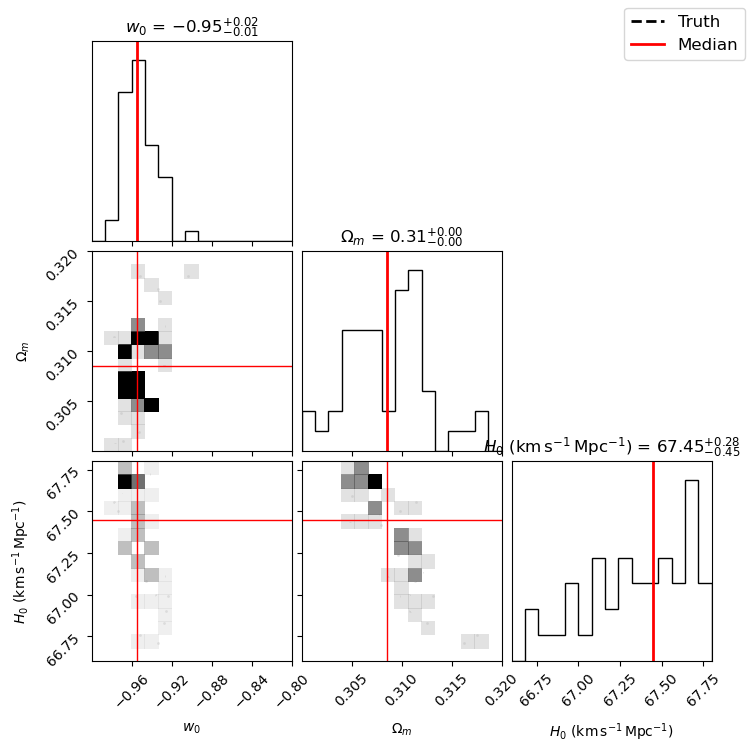

In [16]:


# corner plot
samples_w = np.vstack([
    W,
    Om0w,
    HUBw,
]).T

medianw = [np.median(W), np.median(Om0w), np.median(HUBw)]

ranges = [
    (-1, -0.8),
    (0.3, 0.32),
    (66.6, 67.8),
]


labels =[
    r"$w_0$",
    r"$\Omega_m$",
    r"$H_0\ \mathrm{(km\,s^{-1}\,Mpc^{-1})}$"
]

# Create corner plot
fig = corner.corner(
    samples_w,
    labels=labels,
    show_titles=True,
    range=ranges,
    plot_datapoints=True,
    fill_contours=False,
    plot_contours=False,
    bins=15
)

#Add median lines manually
ndim = samples_w.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(medianw[i], color="red", lw=2)

for i in range(ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axvline(medianw[j], color="red", lw=1)
        ax.axhline(medianw[i], color="red", lw=1)

# Add legend
truth_line = mlines.Line2D([], [], color='black', lw=2, linestyle='--', label='Truth')
median_line = mlines.Line2D([], [], color='red', lw=2, label='Median')

fig.legend(handles=[truth_line, median_line], loc="upper right", fontsize=12)

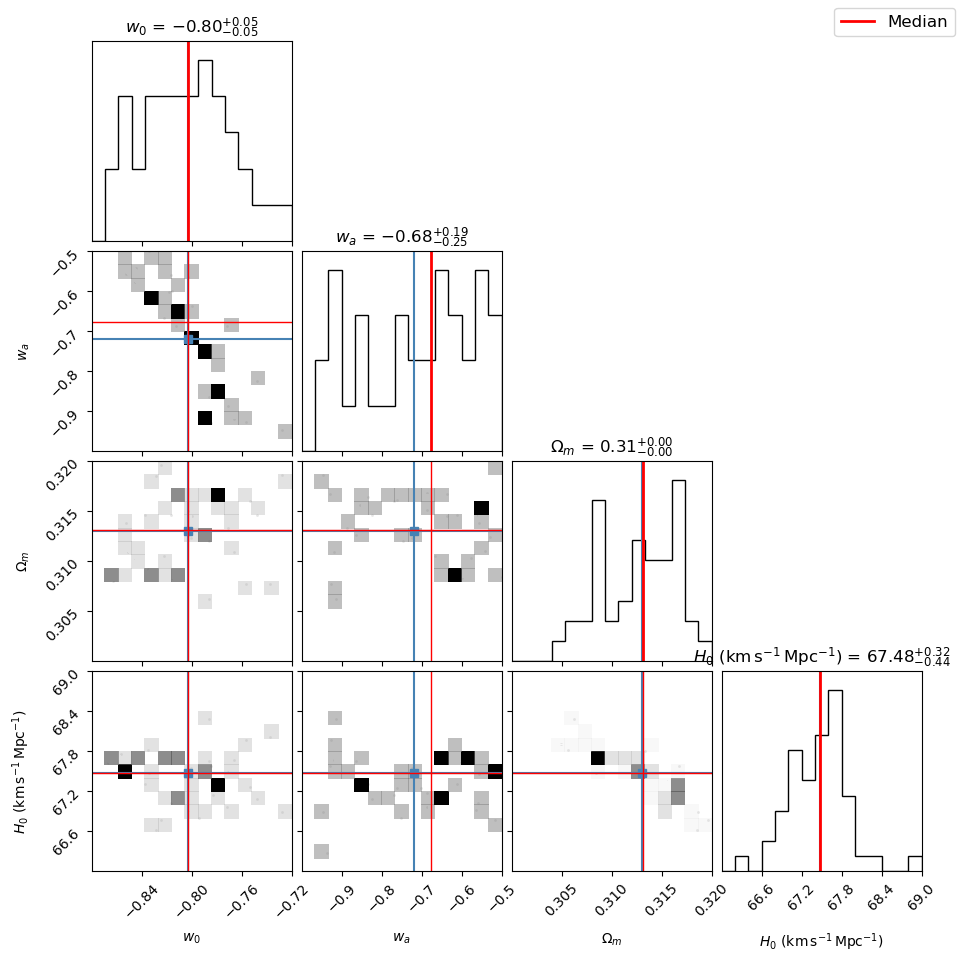

In [17]:
samples_w0wa = np.vstack([
    W0,
    WA,
    Om0waw0,
    HUBwaw0,
]).T 

medianw0wa = [np.median(W0), np.median(WA), np.median(Om0waw0), np.median(HUBwaw0)]

truths = [w, wa, 0.313, H0]

ranges_w0wa = [
    (-0.88, -0.72),
    (-1, -0.5), 
    (0.3, 0.32), 
    (66, 69), 
]

labels2 =[
    r"$w_0$",
    r"$w_a$",
    r"$\Omega_m$",
    r"$H_0\ \mathrm{(km\,s^{-1}\,Mpc^{-1})}$"
]

# Create corner plot
fig = corner.corner(
    samples_w0wa,
    labels=labels2,
    show_titles=True,
    truths = truths,
    range=ranges_w0wa,
    plot_datapoints=True,
    fill_contours=False,
    plot_contours=False,
    bins=15
)

# Add median lines
ndim = samples_w0wa.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(medianw0wa[i], color="red", lw=2, label="Median")

for i in range(ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axvline(medianw0wa[j], color="red", lw=1)
        ax.axhline(medianw0wa[i], color="red", lw=1)

# Add legend
median_line = mlines.Line2D([], [], color='red', lw=2, label='Median')
fig.legend(handles=[median_line], loc="upper right", fontsize=12)

Text(0, 0.5, 'Observed Coverage Fraction')

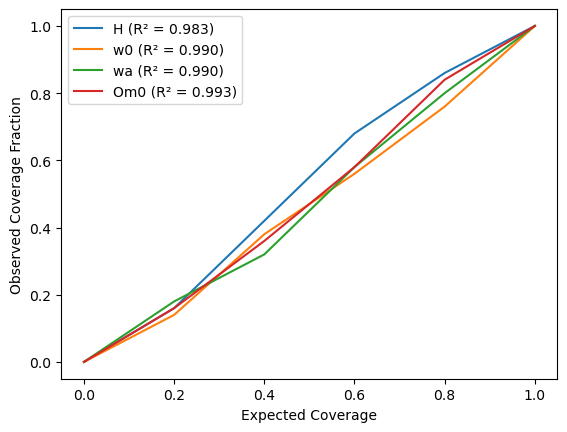

In [18]:
#Coverage test line graph

confidence_regions = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

H_obs = pipeline_checkH/50
w0_obs = pipeline_checkw0/50
wa_obs = pipeline_checkwa/50
Om0_obs = pipeline_checkOm0/50

r2_H = r2_score(confidence_regions, H_obs)
r2_w0 = r2_score(confidence_regions, w0_obs)
r2_wa = r2_score(confidence_regions, wa_obs)
r2_Om0 = r2_score(confidence_regions, Om0_obs)

plt.plot(confidence_regions, H_obs, label=f"H (R² = {r2_H:.3f})")
plt.plot(confidence_regions, w0_obs, label=f"w0 (R² = {r2_w0:.3f})")
plt.plot(confidence_regions, wa_obs, label=f"wa (R² = {r2_wa:.3f})")
plt.plot(confidence_regions, Om0_obs, label=f"Om0 (R² = {r2_Om0:.3f})")

plt.legend()
plt.xlabel("Expected Coverage")
plt.ylabel("Observed Coverage Fraction")

In [19]:
print(np.median(W0), np.std(W0))
print(np.median(WA), np.std(WA))
print(np.median(HUBwaw0), np.std(HUBwaw0))
print(np.median(Om0waw0), np.std(Om0waw0))

print(np.median(W), np.std(W))
print(np.median(HUBw), np.std(HUBw))
print(np.median(Om0w), np.std(Om0w))

print(np.median(HUBL), np.std(HUBL))
print(np.median(Om0L), np.std(Om0L))

-0.8027047413001778 0.057059182093036655
-0.6759115521767847 0.2581868651603732
67.47958744560597 0.4444994019564807
0.3131746816193052 0.004652406804087957
-0.9541597524706782 0.017212298683030473
67.45014734369317 0.4450167991962353
0.3084992642500838 0.004153261949778763
68.32802587343465 0.26976888243723934
0.30264707521308654 0.003412070037634911


In [20]:
#mean preferences for w0waCDM mock data
preference_w0waCDM_over_wCDM = ev_w0wa - ev_w

preference_w0waCDM_over_LCDM = ev_w0wa - ev_L

In [21]:
print(np.mean(preference_w0waCDM_over_LCDM))

4.046638079134616


In [22]:
print(np.mean(preference_w0waCDM_over_wCDM))

4.48462738371841
